# Task 3: Data Visualization & Dashboarding

## Objective
To create professional visualizations using Python libraries such as Matplotlib, Seaborn, and Plotly.

### Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Plotly

### Dataset
Sample Superstore Dataset


In [1]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Display plots inside notebook
%matplotlib inline

## Loading the Dataset

In this step, we load the cleaned Superstore dataset into a Pandas DataFrame.

In [2]:
import os
print(os.getcwd())

E:\Harika Internship 1\apexplanet-data-analytics\notebooks


In [3]:
# Load cleaned dataset

df = pd.read_csv("../data/SampleSuperstore_Cleaned.csv")

# Display first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136
1,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
2,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164
3,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694
4,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656


In [4]:
df.shape

(8827, 21)

# 1. Bar Chart

## Objective
Analyze total sales across different product categories to identify the highest revenue-generating category.

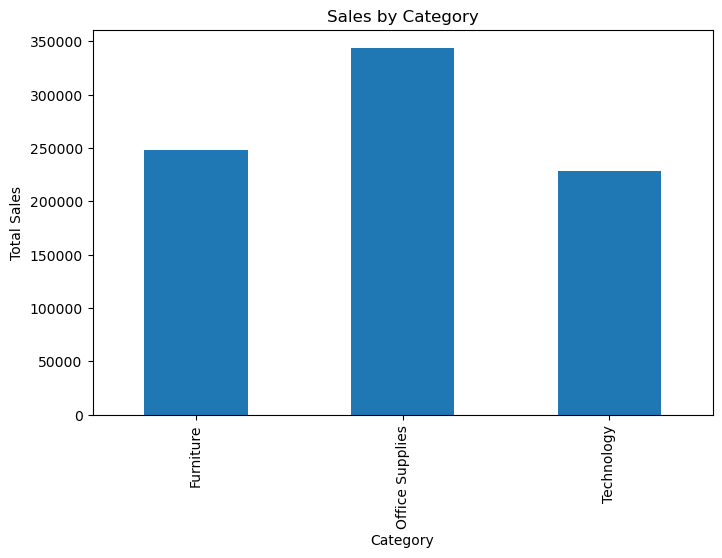

In [5]:
# Calculate total sales by category

sales_category = df.groupby("Category")["Sales"].sum()

# Create bar chart

plt.figure(figsize=(8,5))

sales_category.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.savefig("plots/sales_by_category.png")

plt.show()

# 2. Line Chart

## Objective
Analyze monthly sales trends over time and identify seasonal patterns.

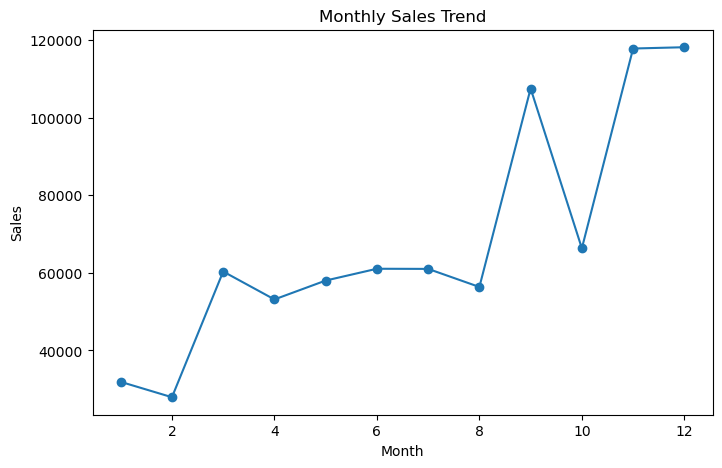

In [6]:
# Convert Order Date to datetime format

df["Order Date"] = pd.to_datetime(df["Order Date"])

# Calculate monthly sales

monthly_sales = df.groupby(df["Order Date"].dt.month)["Sales"].sum()

# Create line chart

plt.figure(figsize=(8,5))

monthly_sales.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.savefig("plots/monthly_sales_trend.png")
plt.show()

# 3. Scatter Plot

## Objective
Analyze the relationship between Sales and Profit and identify any correlation between them.

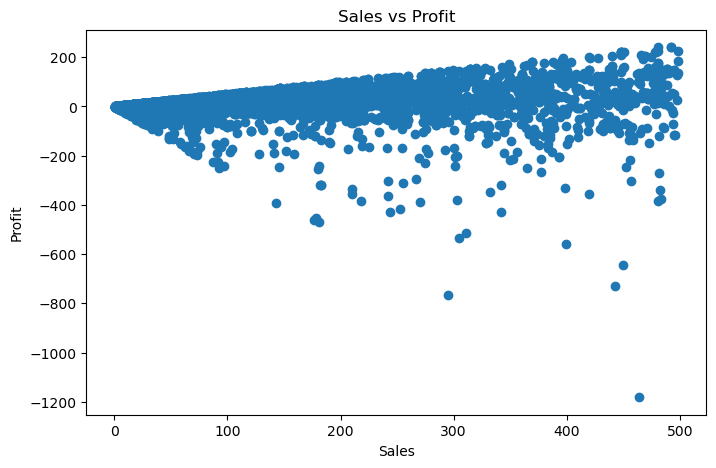

In [7]:
# Create scatter plot

plt.figure(figsize=(8,5))

plt.scatter(
    df["Sales"],
    df["Profit"]
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.savefig("plots/sales_profit_scatter.png")

plt.show()

# 4. Histogram

## Objective
Understand the distribution of sales values and identify sales frequency patterns.

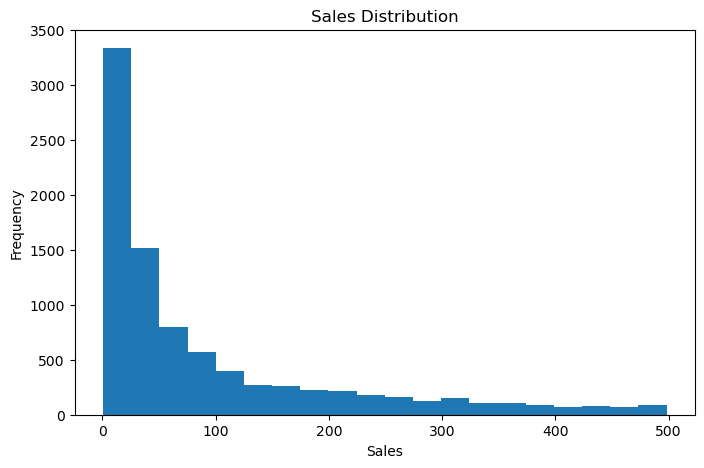

In [8]:
# Create histogram

plt.figure(figsize=(8,5))

plt.hist(
    df["Sales"],
    bins=20
)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.savefig("plots/sales_histogram.png")

plt.show()


# 5. Box Plot

## Objective
Identify the distribution of profit values and detect potential outliers.

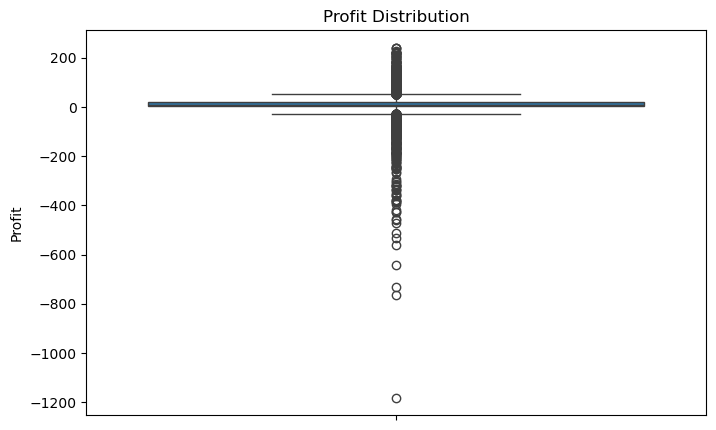

In [9]:
# Create box plot

plt.figure(figsize=(8,5))

sns. boxplot(
    y=df["Profit"]
)

plt.title("Profit Distribution")
plt.savefig("plots/sales_boxplot.png")
plt.show()

# 6. Correlation Heatmap

## Objective
Analyze relationships between numerical variables in the dataset.

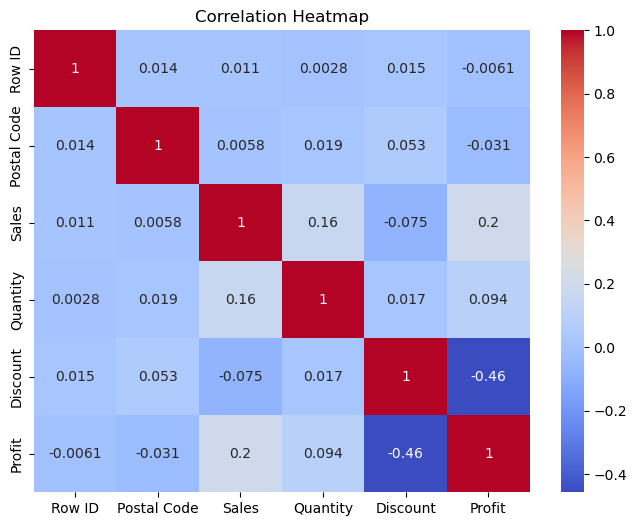

In [10]:
# Select numerical columns

numeric_df = df.select_dtypes(include=["number"])

# Create correlation heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.savefig("plots/correlation_heatmap.png")

plt.show()

# 7. Interactive Plotly Visualization

## Objective
Create an interactive visualization to analyze regional sales performance.

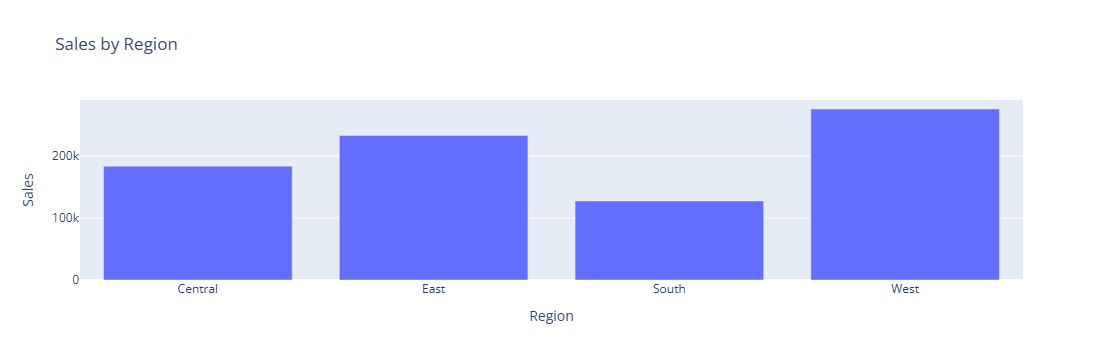

In [11]:
# Calculate sales by region

region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .reset_index()
)

# Create  an interactive bar chart

fig = px.bar(
    region_sales,
    x="Region",
    y="Sales",
    title="Sales by Region"
)
fig.write_html("plots/sales_by_region.html")

fig.show()


In [12]:
import os

os.makedirs("plots", exist_ok=True)

print("plots folder created")

plots folder created


Which customer segment generates the most sales?

## Sales by Segment

This visualization analyzes total sales generated by each customer segment. Understanding segment-wise sales helps identify the customer groups that contribute the most revenue.

In [13]:
# Analyze total sales generated by each customer segment
# This helps identify which customer group contributes the most revenue.


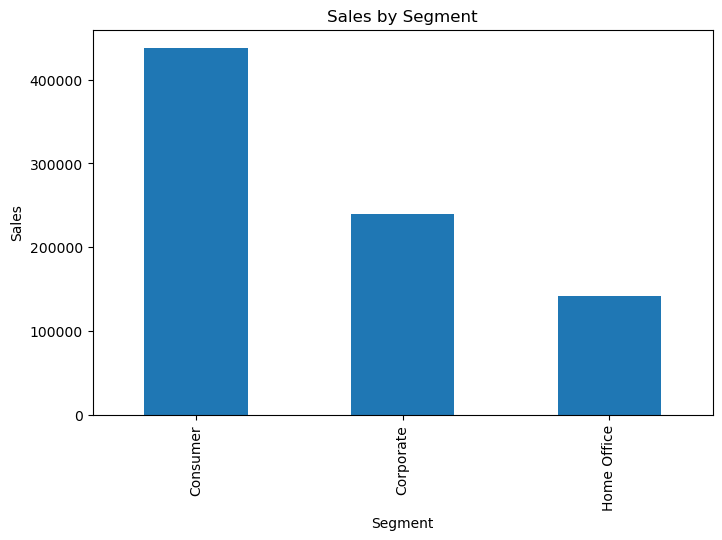

In [14]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
segment_sales.plot(kind="bar")

plt.title("Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.savefig("plots/sales_by_segment.png")

plt.show()

Insight
Consumer usually contributes the highest sales.
Home Office often contributes the lowest.

Which customer segment is most profitable?

## Profit by Segment 
The chart compares the profit contribution of different customer segments to determine which is the most profitable

In [ ]:
# Analyze profit contribution from each customer segment
# Helps determine which customer segment is the most profitable.


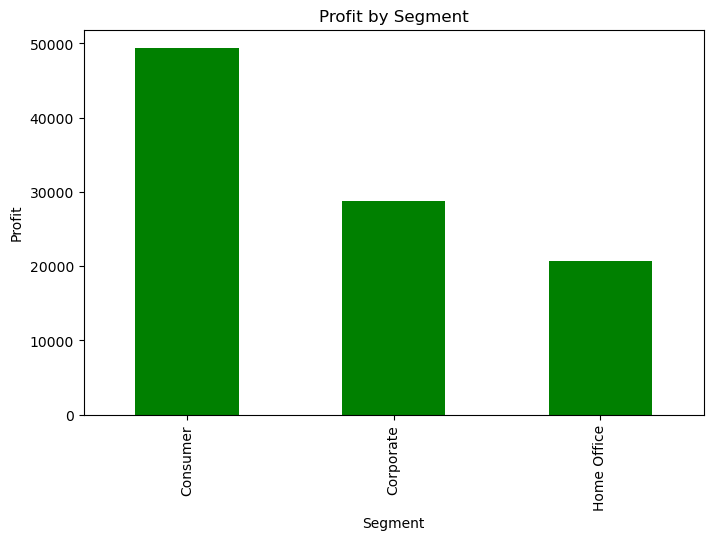

In [16]:
segment_profit = df.groupby("Segment")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
segment_profit.plot(kind="bar", color="green")

plt.title("Profit by Segment")
plt.xlabel("Segment")
plt.ylabel("Profit")
plt.savefig("plots/profit_by_segment.png")


plt.show()

### Insight 
The Consumer segment contributes the highest profit,while the Home Office segment contributes the least . This suggests that
Consumer not only generate high sales but also provide stronger profitability

## Sales by Region

This visualization compares total sales across different geographical regions to identify high-performing markets.

In [17]:
# Compare total sales across different regions
# Useful for identifying high-performing geographical areas.


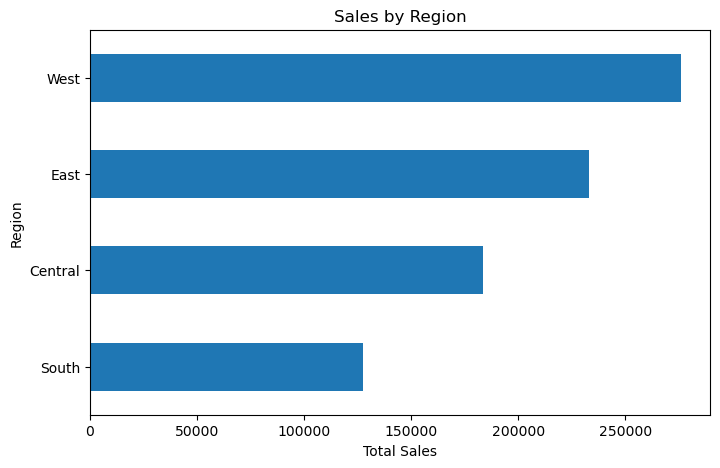

In [18]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values()

plt.figure(figsize=(8,5))
region_sales.plot(kind="barh")

plt.title("Sales by Region")
plt.xlabel("Total Sales")
plt.ylabel("Region")
plt.savefig("plots/sales_by_region.png")


plt.show()

### Insight

The West region records the highest sales, followed by East, Central, and South. This indicates stronger customer demand and market performance in the West region.

In [19]:
Which region generates maximum profit?

Object `profit` not found.


## Profit by Region

This visualization compares the total profit generated across different regions. Analyzing regional profitability helps identify the most profitable markets and supports strategic business decisions.

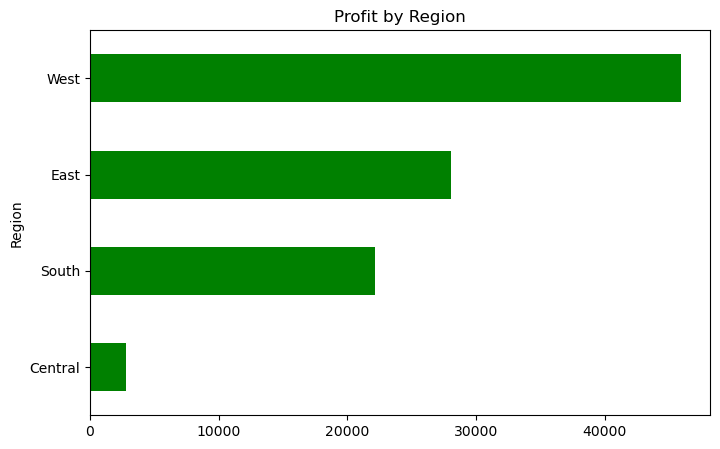

In [20]:
# Analyze profit contribution across different regions
# This helps identify the most profitable geographical markets.

region_profit = df.groupby("Region")["Profit"].sum().sort_values()

plt.figure(figsize=(8,5))
region_profit.plot(kind="barh", color="green")

plt.title("Profit by Region")
plt.savefig("plots/profit_by_region.png")


plt.show()

### Insight

The West region generates the highest profit, indicating strong business performance and effective revenue management in that market. The East region also contributes significantly to overall profitability, while the Central and South regions generate comparatively lower profits. These findings suggest opportunities to improve profitability in lower-performing regions through targeted business strategies.

## Top 10 States by Sales

This chart identifies the top-performing states based on total sales revenue.

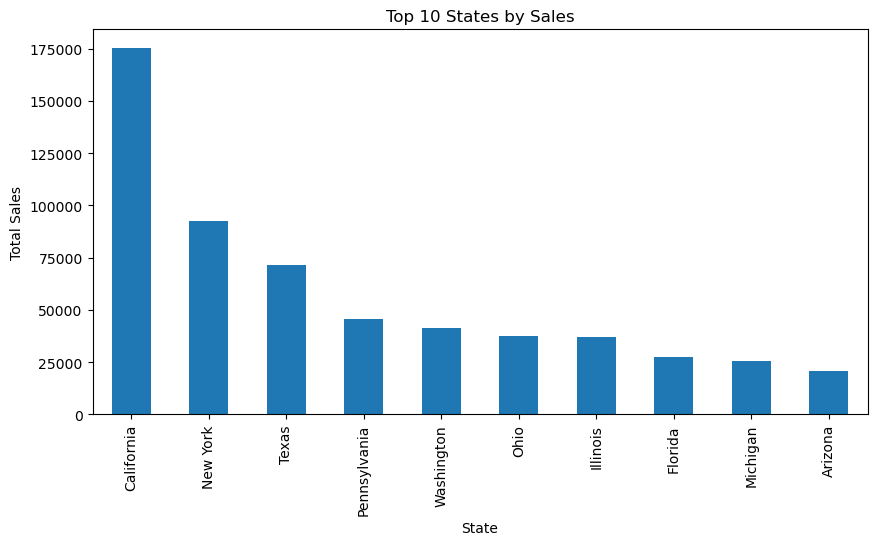

In [21]:
# Identify the top 10 states generating the highest sales
# Helps understand where the business performs best.

top_states = df.groupby("State")["Sales"].sum() \
               .sort_values(ascending=False) \
               .head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind="bar")

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")

plt.show()

### Insight

A few states contribute a significant portion of overall sales. States such as California, New York, and Texas typically dominate revenue generation and represent important business markets.

## Top 10 States by Profit

This visualization identifies the top 10 states generating the highest profit. Analyzing state-wise profitability helps businesses understand their strongest markets and focus resources on regions that contribute the most financial value.

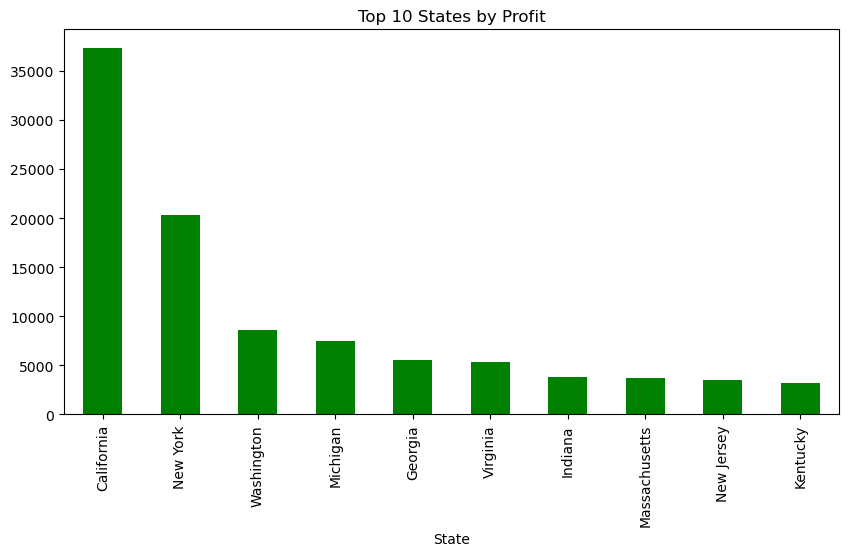

In [22]:
# Identify the top 10 states generating the highest profit
# This helps understand which states contribute most to business profitability.

top_profit_states = df.groupby("State")["Profit"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_profit_states.plot(kind="bar", color="green")

plt.title("Top 10 States by Profit")
plt.savefig("plots/top10_states_profit.png")



plt.show()

### Insight

The chart shows the top 10 states contributing the highest profit to the business. These states represent the most profitable markets and play a crucial role in overall business performance. Focusing on customer retention and growth strategies in these regions can further increase profitability and strengthen market presence.

<Axes: xlabel='Category'>

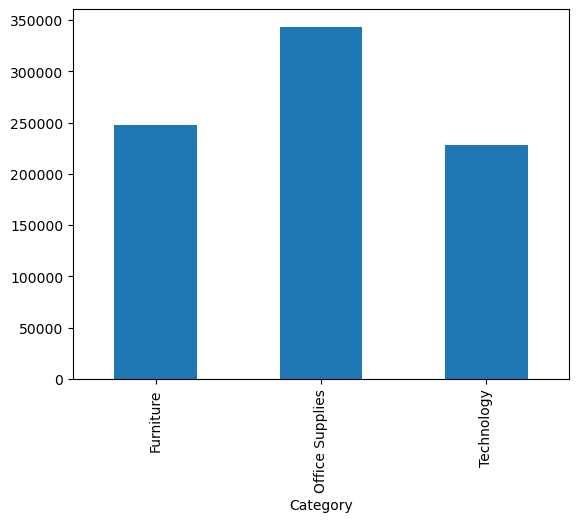

In [23]:
df.groupby("Category")["Sales"].sum().plot(kind="bar")

<Axes: xlabel='Category'>

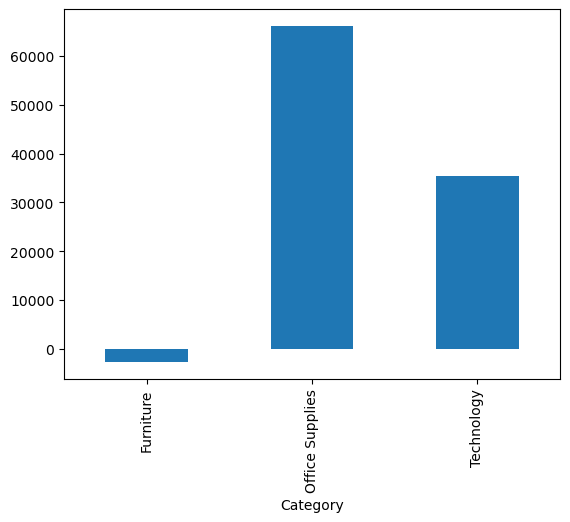

In [24]:
df.groupby("Category")["Profit"].sum().plot(kind="bar")

## Discount vs Profit Analysis

This scatter plot examines the relationship between discounts offered and the resulting profit. Understanding this relationship helps evaluate whether discounting strategies positively or negatively impact business profitability.

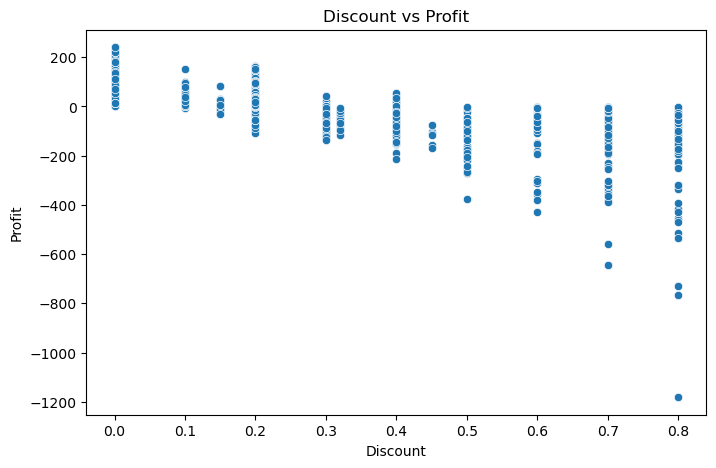

In [25]:
# Analyze the relationship between discount and profit
# This helps determine whether higher discounts affect profitability.

plt.figure(figsize=(8,5))

sns. scatterplot(
    x="Discount",
    y="Profit",
    data=df
)

plt.title("Discount vs Profit")
plt.savefig("plots/discount_vs_profit.png")



plt.show()

### Insight

The scatter plot reveals a generally negative relationship between discount and profit. As discounts increase, profits tend to decrease, and some highly discounted transactions even result in losses. This suggests that excessive discounting can significantly impact business profitability and should be carefully managed.

## Pairwise Relationship Analysis by Customer Segment

This pairplot visualizes relationships among Sales, Profit, Discount, and Quantity while distinguishing customer segments using color coding. It helps identify patterns, correlations, and differences in purchasing behavior across customer segments.

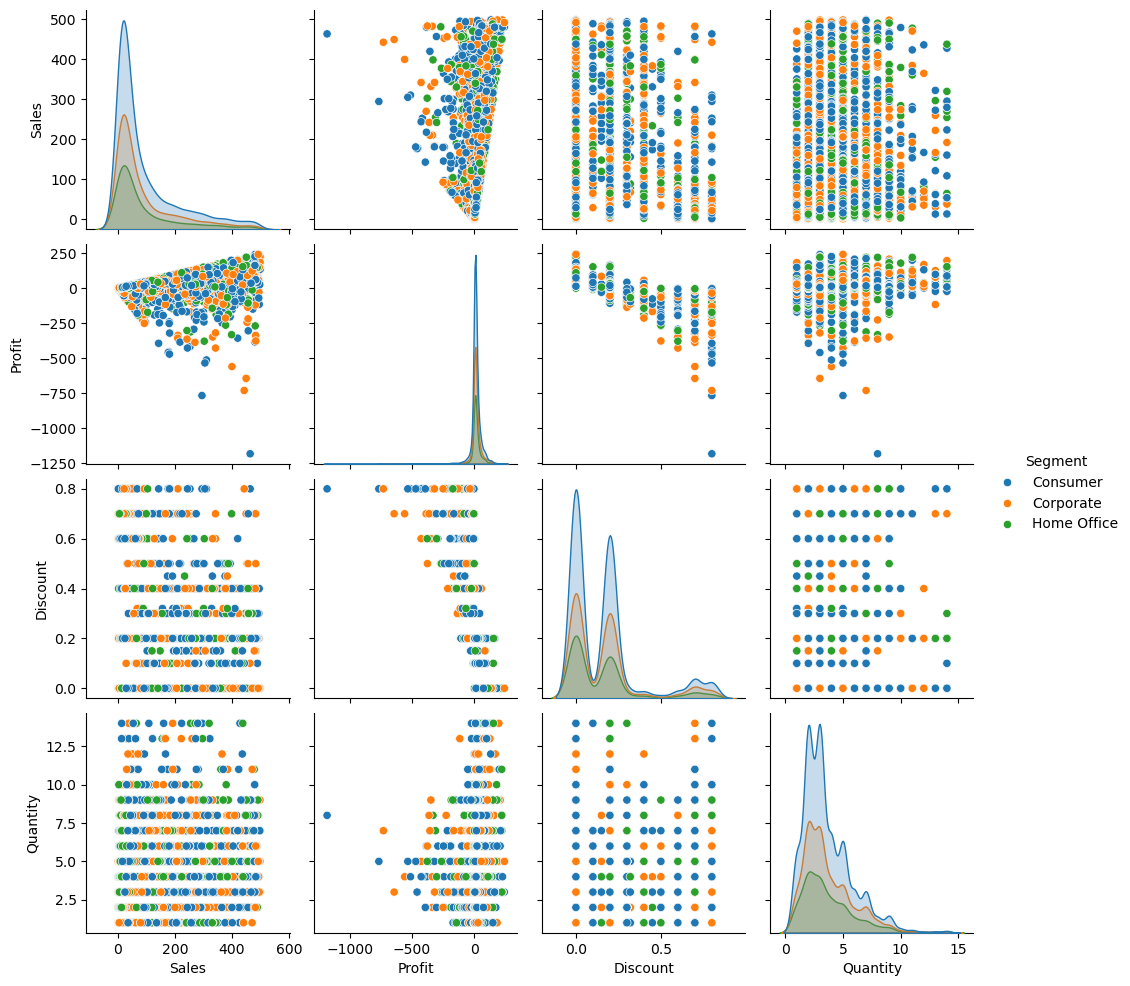

In [26]:
# Analyze pairwise relationships between numerical variables
# Different colors represent different customer segments.
# Helps identify trends, correlations, and segment-specific behavior.
pair_plot = sns.pairplot(
    df[['Sales', 'Profit', 'Discount', 'Quantity', 'Segment']],
    hue='Segment'
)

pair_plot.savefig("plots/pairplot_segment_analysis.png")

plt.show()  

### Insight

The pairplot highlights relationships between key business metrics across customer segments. Sales and Profit show a positive correlation, while higher discounts appear to reduce profitability in certain transactions. The visualization also helps identify segment-specific patterns and potential outliers within the dataset.

## Sales Distribution by Region

This boxen plot visualizes the distribution of sales across different regions. It helps identify variations in sales performance, the spread of sales values, and potential outliers within each region.

In [27]:
# Analyze the distribution of sales across different regions
# Helps identify sales variability, trends, and outliers in each region.

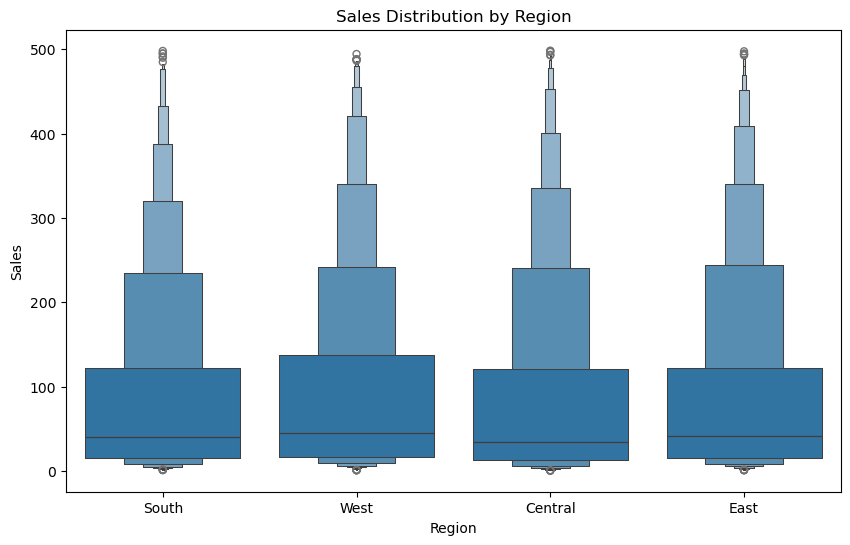

In [28]:
plt.figure(figsize=(10,6))

sns.boxenplot(
    x='Region',
    y='Sales',
    data=df
)

plt.title("Sales Distribution by Region")
plt.savefig("plots/sales_distribution_by_region.png")

plt.show()


### Insight

The boxen plot reveals differences in sales distribution across regions. Some regions show a wider spread of sales values, indicating greater variability in customer purchases, while others exhibit more consistent sales patterns. The presence of outliers suggests that certain transactions generate exceptionally high sales compared to the majority of orders. Understanding these regional differences can help businesses identify strong markets and opportunities for growth.

## Profit Distribution by Customer Segment

This boxen plot visualizes the distribution of profit across different customer segments. It helps identify variations in profitability, profit spread, and unusual transactions within each segment.

In [29]:
# Analyze the distribution of profit across customer segments
# Helps identify profitability patterns, variability, and outliers.

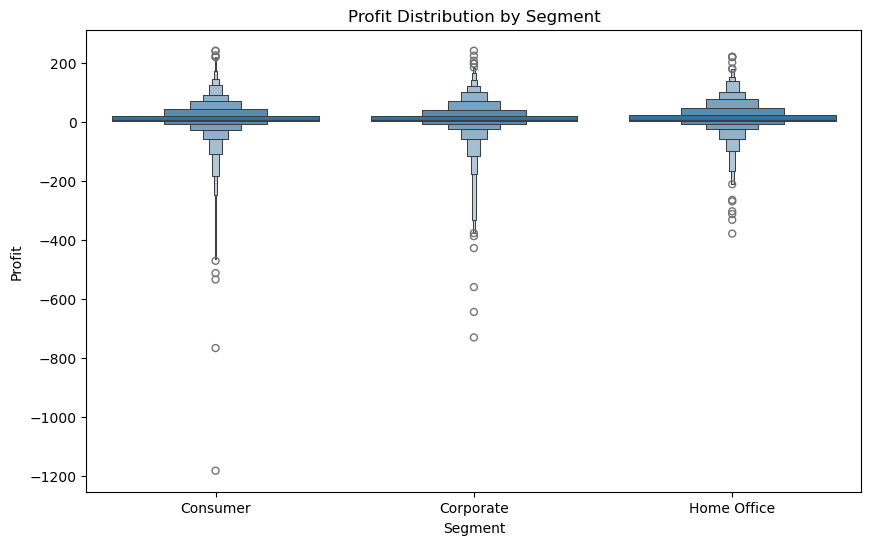

In [30]:
plt.figure(figsize=(10,6))

sns.boxenplot(
    x='Segment',
    y='Profit',
    data=df
)

plt.title("Profit Distribution by Segment")
plt.savefig("plots/profit_distribution_by_segment.png")


plt.show()

### Insight

The boxen plot highlights the distribution of profit across different customer segments. While all segments contribute to profitability, some segments exhibit greater variability in profit values, indicating differences in customer purchasing behavior. The presence of outliers suggests that certain transactions generate exceptionally high profits, while some transactions may result in low or negative profits. Understanding these segment-wise profit patterns can help businesses focus on the most profitable customer groups and improve overall performance.

## Interactive Sales by Segment

This interactive bar chart displays total sales generated by each customer segment. The visualization allows users to explore segment-wise sales performance through interactive features such as hover information and zoom controls.

In [31]:
# Create an interactive bar chart to compare sales across customer segments
# Helps identify which segment contributes the most revenue.

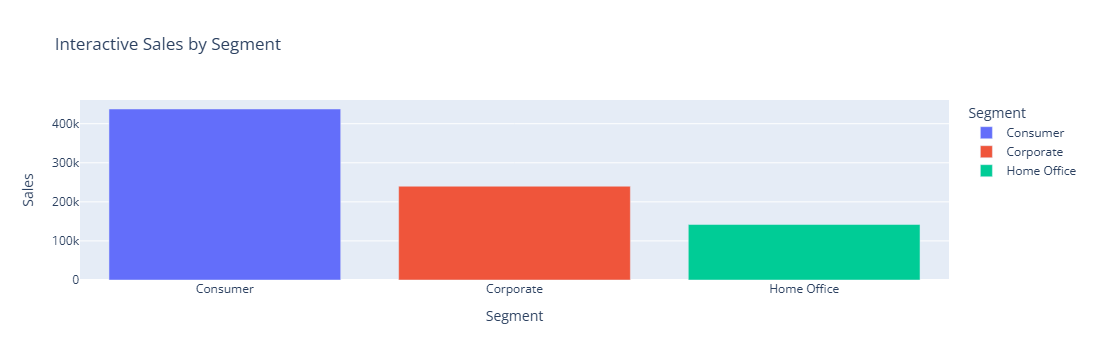

In [32]:
import plotly.express as px

segment_sales = df.groupby("Segment")["Sales"].sum().reset_index()

fig = px.bar(
    segment_sales,
    x="Segment",
    y="Sales",
    color="Segment",
    title="Interactive Sales by Segment"
)
fig.write_html("plots/interactive_sales_by_segment.html")

fig.show()

### Insight

The interactive bar chart shows that the Consumer segment generates the highest sales among all customer segments, followed by Corporate and Home Office. This indicates that Consumer customers are the primary revenue contributors and play a significant role in overall business performance.

## Interactive Profit by Region

This interactive bar chart compares the total profit generated across different regions. The visualization enables users to explore regional profitability through interactive features such as hovering, zooming, and filtering.

In [33]:
# Create an interactive bar chart to compare profit across regions
# Helps identify the most profitable geographical markets.

In [34]:
region_profit = df.groupby("Region")["Profit"].sum().reset_index()

fig = px.bar(
    region_profit,
    x="Region",
    y="Profit",
    color="Region",
    title="Interactive Profit by Region"
)

fig.show() 

### Insight

The interactive visualization shows the profit contribution of each region. The West region generates the highest profit, indicating strong business performance and market presence. Regions with lower profit contributions may require targeted strategies to improve profitability and overall business growth.

In [35]:
segment_sales = df.groupby("Segment")["Sales"].sum().reset_index()
fig = px.pie(
    segment_sales,
    names="Segment",
    values="Sales",
    title="Sales Contribution by Segment"
)

fig.show()

### Insight

The pie chart reveals that the Consumer segment contributes the largest share of total sales, followed by Corporate and Home Office. This indicates that Consumer customers are the primary revenue drivers and have the greatest impact on overall business performance.

## Sales Hierarchy Analysis

This interactive treemap visualizes the hierarchical distribution of sales across product categories and sub-categories. It helps identify the categories and products that contribute the most to overall sales performance.

In [36]:
# Create an interactive treemap to visualize sales hierarchy
# Helps identify top-performing categories and sub-categories.

In [37]:
fig = px.treemap(
    df,
    path=["Category","Sub-Category"],
    values="Sales",
    title="Sales Hierarchy"
)
fig.write_html("plots/sales_hierarchy_treemap.html")


fig.show()

### Insight

The treemap highlights the contribution of each category and sub-category to total sales. Larger rectangles represent higher sales values, making it easy to identify top-performing product groups. The visualization reveals which categories dominate revenue generation and which sub-categories contribute the most within each category.

## Sales vs Profit Analysis

This interactive scatter plot examines the relationship between Sales and Profit across different product categories. The size of each marker represents the quantity sold, while colors distinguish product categories. This visualization helps identify profitable and non-profitable sales transactions.

In [38]:
# Create an interactive scatter plot to analyze the relationship between sales and profit
# Marker size represents quantity sold and color represents product category.

In [39]:
fig = px.scatter(
    df,
    x="Sales",
    y="Profit",
    color="Category",
    size="Quantity",
    hover_data=["Sub-Category"],
    title="Sales vs Profit Analysis"
)
fig.write_html("plots/sales_vs_profit_analysis.html")

fig.show()

### Insight

The scatter plot reveals a generally positive relationship between Sales and Profit, indicating that higher sales often generate higher profits. However, several transactions with high sales produce low or even negative profits, suggesting the impact of heavy discounts, operational costs, or low-margin products. The visualization also highlights differences in performance across product categories and helps identify potential outliers.

## Sales and Profit by State

This interactive geographic visualization displays sales and profit performance across different states. Marker size represents sales volume, while color indicates profit levels. The map helps identify high-performing and low-performing regions geographically.

In [40]:
# Create an interactive geographic visualization of sales and profit by state
# Marker size represents sales and color represents profit.

In [41]:
fig = px.scatter_geo(
    df,
    locations="State",
    locationmode="USA-states",
    size="Sales",
    color="Profit",
    hover_name="State",
    title="Sales and Profit by State"
)
fig.write_html("plots/sales_profit_by_state_map.html")


fig.show()

### Insight

The geographic visualization highlights the distribution of sales and profit across different states. States with larger markers contribute higher sales, while color intensity indicates profitability levels. The map reveals that some states generate both high sales and high profits, whereas others may have strong sales performance but relatively lower profitability. This analysis helps identify key markets and areas that may require strategic improvement.